In [1]:
import sys
!{sys.executable} -m pip install xgboost

scale_pos_weight: 1.61
Best hyperparameters: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1}
Best cross-validation accuracy: 61.43%
XGBoost Accuracy: 0.65 (65.3%)

Confusion Matrix:
[[67 31]
 [21 31]]

Classification Report:
              precision    recall  f1-score   support

   Sensitive       0.76      0.68      0.72        98
   Resistant       0.50      0.60      0.54        52

    accuracy                           0.65       150
   macro avg       0.63      0.64      0.63       150
weighted avg       0.67      0.65      0.66       150


Random Forest Accuracy: 0.65 (64.7%)
XGBoost Accuracy:      0.65 (65.3%)
→ XGBoost performed better!


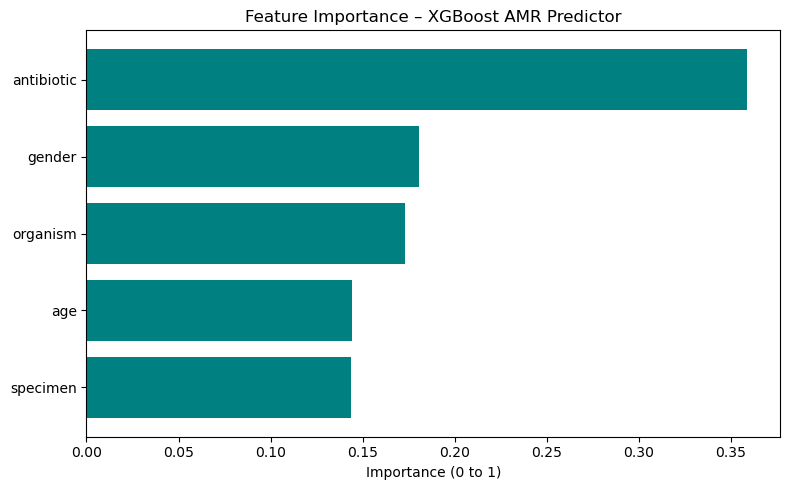

Plot saved as 'feature_importance.png'

XGBoost model saved as 'xgboost_prediction_model.pkl'
Encoders saved as 'feature_encoders.pkl'


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import xgboost as xgb
df = pd.read_csv('antibiotic_resistance_dataset.csv')
X = df.drop('resistant', axis=1)
y = df['resistant']
categorical_cols = ['gender', 'specimen', 'organism', 'antibiotic']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale:.2f}")
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}
base_model = xgb.XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale   
)
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_grid,
    n_iter=10,               
    cv=3,                    
    scoring='accuracy',
    random_state=42,
    n_jobs=-1               
)
random_search.fit(X_train, y_train)
print("Best hyperparameters:", random_search.best_params_)
print("Best cross-validation accuracy: {:.2f}%".format(random_search.best_score_ * 100))
best_xgb = random_search.best_estimator_
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale  
)
best_xgb.fit(X_train, y_train)   
y_pred_xgb = best_xgb.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.2f} ({accuracy_xgb*100:.1f}%)\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=['Sensitive', 'Resistant']
))
try:
    rf_model = joblib.load('prediction_model.pkl')
    y_pred_rf = rf_model.predict(X_test)
    accuracy_rf = accuracy_score(y_test, y_pred_rf)
    print(f"\nRandom Forest Accuracy: {accuracy_rf:.2f} ({accuracy_rf*100:.1f}%)")
    print(f"XGBoost Accuracy:      {accuracy_xgb:.2f} ({accuracy_xgb*100:.1f}%)")
    if accuracy_xgb > accuracy_rf:
        print("→ XGBoost performed better!")
    elif accuracy_xgb < accuracy_rf:
        print("→ Random Forest performed better (this can happen with small datasets).")
    else:
        print("→ Both models have the same accuracy.")
except FileNotFoundError:
    print("\nNo 'prediction_model.pkl' found. Skipping comparison. Run the Random Forest training code first if you want to compare.")
import matplotlib.pyplot as plt
importances = best_xgb.feature_importances_
features = X_train.columns
sorted_idx = importances.argsort()   
plt.figure(figsize=(8, 5))
plt.barh(range(len(features)), importances[sorted_idx], color='teal')
plt.yticks(range(len(features)), features[sorted_idx])
plt.xlabel("Importance (0 to 1)")
plt.title("Feature Importance – XGBoost AMR Predictor")
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Plot saved as 'feature_importance.png'")
joblib.dump(xgb_model, 'axgboost_prediction_model.pkl')
joblib.dump(encoders, 'feature_encoders.pkl')
print("\nXGBoost model saved as 'xgboost_prediction_model.pkl'")
print("Encoders saved as 'feature_encoders.pkl'")

In [3]:

print(df['resistant'].value_counts())
print("\nProportion:")
print(df['resistant'].value_counts(normalize=True) * 100)

resistant
0    314
1    186
Name: count, dtype: int64

Proportion:
resistant
0    62.8
1    37.2
Name: proportion, dtype: float64
